# Latency and stimulus omission responses

This notebook generates the plots for Figure 5. All plots use the retinal model trained for prediction. The pre-trained model can either be downloaded from this repo or can be trained from scatch (see README).

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

from retina import analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

In [2]:
root = os.path.expanduser("~/PycharmProjects/RetinalModel")

## Spike latency

In [3]:
def plot_spike_code(spike_code, v_min, v_max, cmap, ax):
    
    def nicify(ax):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
    
    def add_bar(im, ax):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("bottom", size="4%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
        cbar.ax.tick_params(labelsize=35) 
        cbar.outline.set_linewidth(3)
        cbar.ax.tick_params(width=3)
        
        return cbar
    
    im = ax.imshow(spike_code, vmin=v_min, vmax=v_max, cmap=cmap)
    nicify(ax)
    
    return add_bar(im, ax)

In [5]:
larva_sequence = analysis.get_larva_sequence(root)
latency_query = analysis.LatencyQuery(root, larva_sequence, pred_offset=128)
rel_latency_code = latency_query.to_relative_latency_code(36).cpu()
rate_code = latency_query.to_rate_code().cpu()

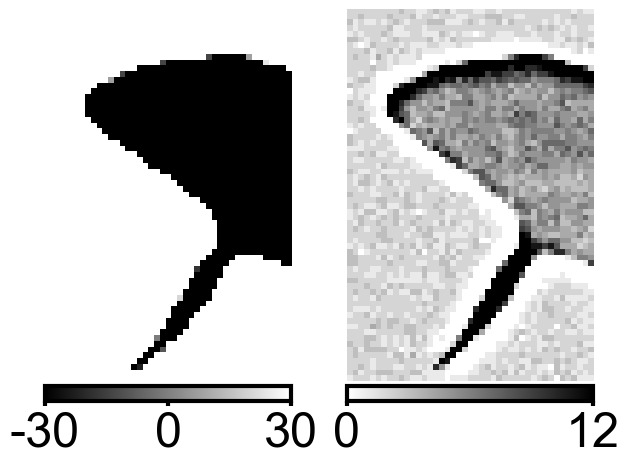

In [6]:
fig, ax = plt.subplots(1, 2)
n = 133

cbar = plot_spike_code(rel_latency_code[0, n], -7, 7, "gray", ax[0])
cbar.set_ticks([-7, 0, 7])
cbar.set_ticklabels(["-30", "0", "30"])
cbar = plot_spike_code(rate_code[0, n], 0, 12, "gray_r", ax[1])
cbar.set_ticks([0, 12])
cbar.set_ticklabels(["0", "12"])
fig.tight_layout()
plt.savefig(f"{root}/figures/fig5/single_cell_spike_decoding.svg", format="svg", transparent=False, bbox_inches="tight")

## Decoder noise-reconstructed input

In [7]:
def plot_neural_code_decoder_cc(decoder_cc_df, ax):
    _decoder_cc_df = decoder_cc_df.copy()
    _decoder_cc_df["code"] = _decoder_cc_df["code"].map({"latency": "Latency-decoding", "rate": "Rate-decoding"})
    
    sns.lineplot(_decoder_cc_df, x="noise", y="cc", hue="code", errorbar="se", ax=ax)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.xaxis.set_tick_params(width=3, labelsize=18, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=18, pad=8)
    ax.set_xlabel("Added image noise $\sigma$", fontsize=22, labelpad=8)
    ax.set_ylabel("Decoded CC", fontsize=22, labelpad=8)
    ax.set_xlim([0, 2])
    ax.set_ylim([0, 0.8])
    
    current_handles, current_labels = ax.get_legend_handles_labels()
    ax.legend(current_handles, current_labels, title="", fontsize=16, title_fontsize=16, frameon=False, alignment="left")


In [ ]:
ln_fit_builder = analysis.LNFitAccBuilder(root)
decoder_cc_df = ln_fit_builder.build_all_fit_df()

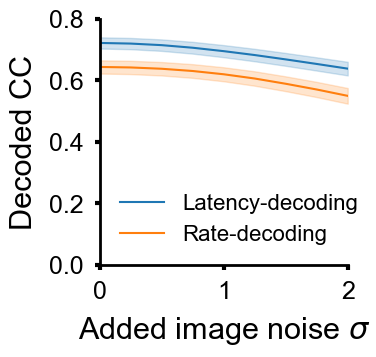

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(3.2, 3.2))

plot_neural_code_decoder_cc(decoder_cc_df, ax)
plt.savefig(f"{root}/figures/fig5/population_decoding_cc.svg", format="svg", transparent=False, bbox_inches="tight")

In [17]:
def plot_sample_decoded_images(decoded_images_list, axs):
    for col_idx in range(6):
        for row_idx in range(4):
            axs[row_idx, col_idx].imshow(decoded_images_list[col_idx][4 - (row_idx + 1)], cmap="Greys", vmin=-1, vmax=1)
            axs[row_idx, col_idx].spines["right"].set_linewidth(2)
            axs[row_idx, col_idx].spines["top"].set_linewidth(2)
            axs[row_idx, col_idx].spines["left"].set_linewidth(2)
            axs[row_idx, col_idx].spines["bottom"].set_linewidth(2)
            axs[row_idx, col_idx].set_xticks([])
            axs[row_idx, col_idx].set_yticks([])

In [18]:
decoded_images_list = []

for image_idx in [17, 6]:
    for noise in [0.0, 1.0, 2.0]:
        decoded_images_list.append(analysis.LNFitAccBuilder.get_list_images(root, noise, image_idx))

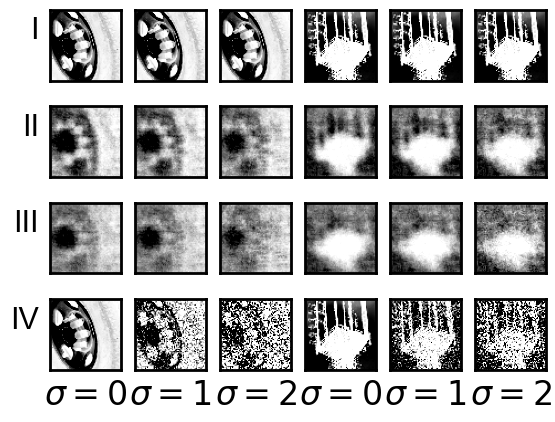

In [19]:
fig, axs = plt.subplots(4, 2*3)
plot_sample_decoded_images(decoded_images_list, axs)
# x-labels
axs[3, 0].set_xlabel("$\sigma=0$", fontsize=24, labelpad=8)
axs[3, 1].set_xlabel("$\sigma=1$", fontsize=24, labelpad=8)
axs[3, 2].set_xlabel("$\sigma=2$", fontsize=24, labelpad=8)
axs[3, 3].set_xlabel("$\sigma=0$", fontsize=24, labelpad=8)
axs[3, 4].set_xlabel("$\sigma=1$", fontsize=24, labelpad=8)
axs[3, 5].set_xlabel("$\sigma=2$", fontsize=24, labelpad=8)
# y-labels
axs[0, 0].set_ylabel("I", fontsize=22, labelpad=8, rotation=0, ha="right")
axs[1, 0].set_ylabel("II", fontsize=22, labelpad=8, rotation=0, ha="right")
axs[2, 0].set_ylabel("III", fontsize=22, labelpad=8, rotation=0, ha="right")
axs[3, 0].set_ylabel("IV", fontsize=22, labelpad=8, rotation=0, ha="right")
plt.savefig(f"{root}/figures/fig5/population_decoding_examples.svg", format="svg", transparent=False, bbox_inches="tight")

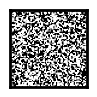

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(1, 1))

def plot_frame(frame, ax):
    ax.imshow(frame, vmin=-1, vmax=1, cmap="Greys")
    ax.spines["right"].set_linewidth(2)
    ax.spines["top"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])

noise_frame = analysis.LNFitAccBuilder(root, noise=2.0, code="latency")
plot_frame(noise_frame.test_dataset.noise_frame[0], ax)

## Omitted stimulus response

In [11]:
ors_query_12hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=12)

In [12]:
def get_last_flash_onset(ors_query, units='ms'):
    flash_train = ors_query.flash_clip
    indexes_of_negatives = np.where(np.diff(flash_train) < 0)[0]
    last_flash_onset = indexes_of_negatives[-1] + 1  # +1 to get the actual onset index

    if units == 'ms':
        return last_flash_onset * 4.333
    elif units == 'time_bins':
        return last_flash_onset
    else:
        raise ValueError("units must be either 'ms' or 'time_bins'")

def plot_osr(ors_query, intesity_ax, max_r, idx, d, firing_ax, plot_latency=False, input_current=False):

    last_flash_onset = get_last_flash_onset(ors_query,'time_bins')
    
    intesity_ax.plot(ors_query.flash_clip, c="black", linewidth=2)
    intesity_ax.spines["top"].set_visible(False)
    intesity_ax.spines["right"].set_visible(False)
    intesity_ax.spines["bottom"].set_visible(False)
    intesity_ax.spines["left"].set_linewidth(2)
    
    fs = 14
    intesity_ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    intesity_ax.set_yticks([0, 1])
    intesity_ax.set_xlim([0, len(ors_query.flash_clip)])
    intesity_ax.set_xticks([])
    intesity_ax.set_xticklabels([])
    intesity_ax.set_xlabel("")
    
    #firing_ax.plot([last_flash_onset, last_flash_onset], [0, 1], "--", c="black", linewidth=2)
    firing_ax.plot([388-d, 388-d], [0, 1], "--", c="black", linewidth=2)

    color = '#1f77b4'
    if input_current:
        input_current = ors_query.smooth_input_current[idx]
        firing_ax.plot(input_current, linewidth=3, c=color)
    else:
        firing_rate = ors_query.firing_rate[idx]
        firing_ax.plot(firing_rate, linewidth=3, c=color)

    firing_ax.set_xticks([0, 36, 36+120, 36+2*120, 36+3*120])
    firing_ax.set_xticklabels(["", "0", "0.5", "1.0", "1.5"]) 
    
    firing_ax.spines["top"].set_visible(False)
    firing_ax.spines["right"].set_visible(False)
    firing_ax.spines["bottom"].set_linewidth(2)
    firing_ax.spines["left"].set_linewidth(2)
    firing_ax.set_xlim([0, len(ors_query.flash_clip)])
    firing_ax.set_ylim([0., 1.1*max_r])
    firing_ax.set_yticks([0, max_r])
    firing_ax.set_yticklabels(["0", f"{int(max_r * (240))}"])
    firing_ax.xaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    firing_ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    firing_ax.set_xlabel("Time (s)", fontsize=fs, labelpad=8)
    firing_ax.set_ylabel("Firing rate (Hz)", fontsize=fs, labelpad=10)
    
    return last_flash_onset*4.333

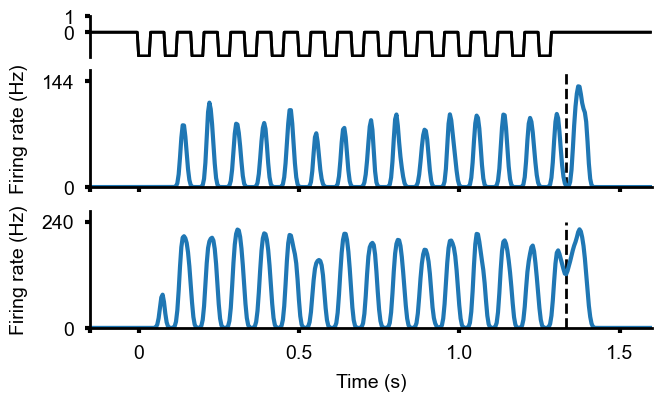

In [15]:
#Plot 12Hz OSR
fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-15+9+1-7
plot_osr(ors_query_12hz, intesity_ax, 0.6, 21, d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_12hz, intesity_ax, 1, 349, d, firing2_ax)
plt.savefig(f"{root}/figures/supp/12hz_new.svg", format="svg", transparent=False, bbox_inches="tight")